# AdapTrap - Continual Learning Model
Runs both checkpoints (static M1 on Batch 1, adaptive M2 on Batch1+Batch2) and computes BWT/FWT.

- **Checkpoint 1**: train M1 on Batch 1 only. Evaluate on Batch 1 holdout -> R(1,1). Evaluate on Batch 2 holdout (no retrain) -> R(1,2) = Forward Transfer.
- **Checkpoint 2**: retrain M2 on Batch1+Batch2 cumulative. Evaluate on Batch 1 holdout -> R(2,1) = Backward Transfer check. Evaluate on Batch 2 holdout -> R(2,2).
- **BWT** = R(2,1) - R(1,1)
- **FWT** = R(1,2)

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.neural_network import MLPRegressor

from adaptrap_pipeline import (
    process_batch, get_feature_cols, fit_scaler,
    assign_dominant_protocol, stratified_three_way_split, tune_contamination,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


c:\Users\Lazaro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Step 1 - Process both batches through the identical pipeline

In [2]:
BATCH_1_PATH = "CICHoneynet_July1.csv"       # July 2 (day 1)
BATCH_2_PATH = "CICHoneynet_July2-9.csv"     # July 2-9 (full week, cumulative capture)

batch1_profiles = process_batch(BATCH_1_PATH)
batch2_profiles = process_batch(BATCH_2_PATH)

# Section 3.4.2: traffic-class label used for stratified splitting
batch1_profiles = assign_dominant_protocol(batch1_profiles)
batch2_profiles = assign_dominant_protocol(batch2_profiles)

print(f"Batch 1 attacker profiles: {batch1_profiles.shape}")
print(f"Batch 2 attacker profiles: {batch2_profiles.shape}")


c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()


Batch 1 attacker profiles: (1179, 25)
Batch 2 attacker profiles: (4485, 25)


c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()


## Step 2 - Shared feature space + scaler fit on the union of both batches

In [3]:
feature_cols = sorted(set(get_feature_cols(batch1_profiles)) | set(get_feature_cols(batch2_profiles)))
for col in feature_cols:
    if col not in batch1_profiles.columns:
        batch1_profiles[col] = 0
    if col not in batch2_profiles.columns:
        batch2_profiles[col] = 0

combined_for_scaling = pd.concat([batch1_profiles[feature_cols], batch2_profiles[feature_cols]])
scaler = fit_scaler(combined_for_scaling.assign(**{"__dummy__": 0}).drop(columns="__dummy__"), feature_cols)

def scale(profiles):
    return scaler.transform(profiles[feature_cols])


## Step 3 - Per-batch train/holdout splits

In [4]:
b1_train_idx, b1_val_idx, b1_test_idx = stratified_three_way_split(
    batch1_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)
b2_train_idx, b2_val_idx, b2_test_idx = stratified_three_way_split(
    batch2_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)

X1_train = scale(batch1_profiles.iloc[b1_train_idx])
X1_val   = scale(batch1_profiles.iloc[b1_val_idx])
X1_test  = scale(batch1_profiles.iloc[b1_test_idx])   # holdout - final eval only

X2_train = scale(batch2_profiles.iloc[b2_train_idx])
X2_val   = scale(batch2_profiles.iloc[b2_val_idx])
X2_test  = scale(batch2_profiles.iloc[b2_test_idx])   # holdout - final eval only

X_cumulative_train = np.vstack([X1_train, X2_train])
X_cumulative_val   = np.vstack([X1_val, X2_val])      # "updated validation set" for checkpoint 2

print(f"Batch1 train/val/holdout: {len(X1_train)}/{len(X1_val)}/{len(X1_test)}")
print(f"Batch2 train/val/holdout: {len(X2_train)}/{len(X2_val)}/{len(X2_test)}")
print(f"Cumulative train        : {len(X_cumulative_train)}")
print(f"Cumulative validation   : {len(X_cumulative_val)}")


Batch1 train/val/holdout: 825/177/177
Batch2 train/val/holdout: 3139/673/673
Cumulative train        : 3964
Cumulative validation   : 850


## Step 4 - Reusable evaluation function (Section 3.4.1 metric suite)

In [5]:
def evaluate_checkpoint(model, X_train_used, X_test, label):
    raw_pred = model.predict(X_test)
    flags = (raw_pred == -1).astype(int)
    scores = model.decision_function(X_test)
    anomaly_scores = -scores

    flagging_rate = flags.mean()
    sil = silhouette_score(X_test, flags) if len(set(flags)) > 1 else np.nan

    print(f"--- {label} ---")
    print(f"  Flagging Rate         : {flagging_rate:.2%}")
    print(f"  Anomaly Score (mean)  : {anomaly_scores.mean():.4f} (std {anomaly_scores.std():.4f})")
    print(f"  Silhouette Coefficient: {sil:.4f}" if not np.isnan(sil) else "  Silhouette Coefficient: N/A")
    print()

    return {"label": label, "flagging_rate": flagging_rate,
            "anomaly_score_mean": anomaly_scores.mean(),
            "silhouette": sil}

## Checkpoint 1 - Static model M1 (trained on Batch 1 only)

In [6]:
# Section 3.3.3: tune contamination on Batch 1's own validation set,
# fixed before either holdout set is evaluated
contamination_1, m1, contamination_results_1 = tune_contamination(
    X1_train, X1_val, random_state=RANDOM_SEED
)
print("Checkpoint 1 contamination tuning (Batch 1 validation set):")
print(contamination_results_1)
print(f"Selected contamination: {contamination_1}\n")

r11 = evaluate_checkpoint(m1, X1_train, X1_test, "R(1,1): M1 on Batch 1 holdout")
r12 = evaluate_checkpoint(m1, X1_train, X2_test, "R(1,2): M1 on Batch 2 holdout [Forward Transfer check]")


Checkpoint 1 contamination tuning (Batch 1 validation set):
    contamination  flagging_rate  silhouette
0          0.0100       0.000000         NaN
1          0.0125       0.005650    0.715050
2          0.0150       0.005650    0.715050
3          0.0175       0.011299    0.726404
4          0.0200       0.011299    0.726404
5          0.0500       0.045198    0.536642
6          0.0750       0.050847    0.505172
7          0.1000       0.067797    0.514648
8          0.1250       0.084746    0.477508
9          0.1500       0.129944    0.402385
10         0.2000       0.209040    0.305958
Selected contamination: 0.0175

--- R(1,1): M1 on Batch 1 holdout ---
  Flagging Rate         : 1.13%
  Anomaly Score (mean)  : -0.1770 (std 0.0627)
  Silhouette Coefficient: 0.7150

--- R(1,2): M1 on Batch 2 holdout [Forward Transfer check] ---
  Flagging Rate         : 1.63%
  Anomaly Score (mean)  : -0.1745 (std 0.0643)
  Silhouette Coefficient: 0.6812



### Checkpoint 1 contamination sweep visualization

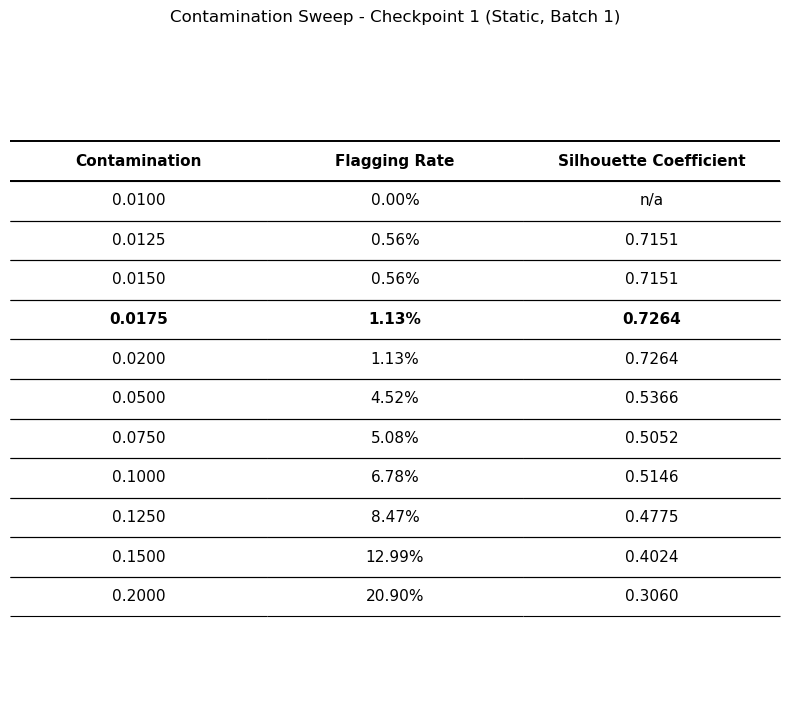

In [8]:
import matplotlib.pyplot as plt

def render_contamination_table(contamination_results, selected_contamination, title):
    df = contamination_results.copy()
    df["contamination"] = df["contamination"].map(lambda v: f"{v:.4f}")
    df["flagging_rate"] = df["flagging_rate"].map(lambda v: f"{v*100:.2f}%")
    df["silhouette"] = df["silhouette"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.4f}")
    df.columns = ["Contamination", "Flagging Rate", "Silhouette Coefficient"]

    highlight_row = contamination_results.index[
        contamination_results["contamination"] == selected_contamination
    ]
    highlight_row = highlight_row[0] if len(highlight_row) else None

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(df) + 1.3))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.0)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.visible_edges = "horizontal"
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.4)
        if highlight_row is not None and row == highlight_row + 1:
            cell.set_facecolor("#d5f5e3")
            cell.set_text_props(weight="bold")

    plt.title(title, fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

render_contamination_table(
    contamination_results_1, contamination_1,
    title="Contamination Sweep - Checkpoint 1 (Static, Batch 1)",
)


## Checkpoint 2 - Adaptive model M2 (retrained on Batch1 + Batch2, SAME contamination reused from checkpoint 1)

In [9]:
contamination_2 = contamination_1  # reuse the static model's tuned value
m2 = IsolationForest(
    n_estimators=100, contamination=contamination_2,
    max_samples="auto", random_state=RANDOM_SEED,
)
m2.fit(X_cumulative_train)
print(f"Checkpoint 2 contamination (reused from static model): {contamination_2}\n")

r21 = evaluate_checkpoint(m2, X_cumulative_train, X1_test, "R(2,1): M2 on Batch 1 holdout [Backward Transfer check]")
r22 = evaluate_checkpoint(m2, X_cumulative_train, X2_test, "R(2,2): M2 on Batch 2 holdout")


Checkpoint 2 contamination (reused from static model): 0.0175

--- R(2,1): M2 on Batch 1 holdout [Backward Transfer check] ---
  Flagging Rate         : 1.69%
  Anomaly Score (mean)  : -0.1645 (std 0.0614)
  Silhouette Coefficient: 0.6697

--- R(2,2): M2 on Batch 2 holdout ---
  Flagging Rate         : 1.93%
  Anomaly Score (mean)  : -0.1660 (std 0.0643)
  Silhouette Coefficient: 0.6702



## Backward / Forward Transfer summary

In [10]:
BWT = r21["silhouette"] - r11["silhouette"]
FWT = r12["silhouette"]

print(f"R(1,1) Static  on Batch1 : {r11['silhouette']:.4f}")
print(f"R(2,1) Adaptive on Batch1: {r21['silhouette']:.4f}")
print(f"BWT = R(2,1) - R(1,1)    : {BWT:+.4f}  "
      f"({'stable/no forgetting' if BWT >= -0.02 else 'possible forgetting'})")
print()
print(f"R(1,2) Static on Batch2: {r12['silhouette']:.4f}")
print(f"FWT = R(1,2): {FWT:+.4f}  "
      f"({'generalizes forward' if FWT > 0 else 'poor forward generalization'})")


R(1,1) Static  on Batch1 : 0.7150
R(2,1) Adaptive on Batch1: 0.6697
BWT = R(2,1) - R(1,1)    : -0.0453  (possible forgetting)

R(1,2) Static on Batch2: 0.6812
FWT = R(1,2): +0.6812  (generalizes forward)


## Checkpoint comparison table

In [11]:
summary = pd.DataFrame([r11, r12, r21, r22])
summary


,label,flagging_rate,anomaly_score_mean,silhouette
0,"R(1,1): M1 on Batch 1 holdout",0.011299,-0.177042,0.714975
1,"R(1,2): M1 on Batch 2 holdout [Forward Transfe...",0.016345,-0.174511,0.681239
2,"R(2,1): M2 on Batch 1 holdout [Backward Transf...",0.016949,-0.164508,0.669690
3,"R(2,2): M2 on Batch 2 holdout",0.019316,-0.166007,0.670162


## Firewall rule generation -- adaptive model (M2)

In [12]:
# Now importing get_representative_ports and generate_rules directly
# from adaptrap_pipeline.py, rather than redefining them locally --
# keeps one shared implementation instead of a copy that could drift
# out of sync with the pipeline file.
from adaptrap_pipeline import get_representative_ports, generate_rules

port_lookup_b1 = get_representative_ports(BATCH_1_PATH)
port_lookup_b2 = get_representative_ports(BATCH_2_PATH)

rules_m2_batch1 = generate_rules(
    m2, X1_test, batch1_profiles.iloc[b1_test_idx], port_lookup_b1,
    label="M2 (Adaptive) on Batch 1 holdout"
)
rules_m2_batch2 = generate_rules(
    m2, X2_test, batch2_profiles.iloc[b2_test_idx], port_lookup_b2,
    label="M2 (Adaptive) on Batch 2 holdout"
)



--- M2 (Adaptive) on Batch 1 holdout ---
        source_ip    port  anomaly_score               action
0  222.71.127.234  1433.0       0.085593  ESCALATE_TO_ANALYST
1     218.92.0.60    22.0       0.023943  ESCALATE_TO_ANALYST
2   79.124.56.106  5900.0       0.008674  ESCALATE_TO_ANALYST
3    195.3.147.52    22.0      -0.002351  ESCALATE_TO_ANALYST
4    47.252.29.89  5432.0      -0.029375  ESCALATE_TO_ANALYST
5    185.94.111.1     NaN      -0.030465  ESCALATE_TO_ANALYST
6   94.232.43.203  5900.0      -0.030938  ESCALATE_TO_ANALYST
7   95.214.55.244    80.0      -0.045056  ESCALATE_TO_ANALYST
8    218.92.0.112    22.0      -0.050873  ESCALATE_TO_ANALYST
9     218.92.0.23    22.0      -0.058996  ESCALATE_TO_ANALYST

ESCALATE_TO_ANALYST: 53, ALLOW: 124
(No records are auto-blocked. BLOCK is an analyst decision made after reviewing an ESCALATE_TO_ANALYST record, not an automated label.)

--- M2 (Adaptive) on Batch 2 holdout ---
         source_ip     port  anomaly_score               acti